# Stage 03: Python Fundamentals

Stage 03. **I based it on the lecture notebook.**

In [1]:
# Install missing packages (uncomment and run to install).
# !pip install numpy pandas matplotlib

In [2]:
from pathlib import Path

# Project root.
ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "prismatic_evoluations_prices.csv").exists() and (
    ROOT.parent / "data" / "raw" / "prismatic_evoluations_prices.csv"
).exists():
    ROOT = ROOT.parent

CHECKS = [
    ("data/raw/prismatic_evoluations_prices.csv", "NEEDED", "Prismatic Evolutions prices"),
    ("src/utils.py", "NEEDED", "helper module the notebook imports"),
]

print(f"Looking in: {ROOT}\n")
missing = 0
for rel, kind, note in CHECKS:
    here = (ROOT / rel).exists()
    if not here and kind == "NEEDED":
        missing += 1
    print(f"  [{'OK ' if here else 'MISS'}]  {kind:<8}  {rel:<34}  {note}")

if missing:
    raise FileNotFoundError(f"{missing} needed file(s) missing under {ROOT}")
print("\nAll needed files present.")

Looking in: /Users/ghostof0days/projects/bootcamp/project

  [OK ]  NEEDED    data/raw/prismatic_evoluations_prices.csv  Prismatic Evolutions prices
  [OK ]  NEEDED    src/utils.py                        helper module the notebook imports

All needed files present.


In [3]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Import helpers from src/.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Raw CSV.
RAW_CSV = ROOT / "data" / "raw" / "prismatic_evoluations_prices.csv"
# Processed outputs.
PROCESSED_DIR = ROOT / "data" / "processed"

## NumPy operations

In [4]:
# Sample card prices.
sample_prices = np.array([145.0, 98.0, 72.0, 18.5, 0.25])
pct_of_top = sample_prices / sample_prices.max() * 100

print("Sample card prices:", sample_prices)
print("As % of top card:", pct_of_top.round(1))

Sample card prices: [145.    98.    72.    18.5    0.25]
As % of top card: [100.   67.6  49.7  12.8   0.2]


## Loop vs. vectorization

In [5]:
big_array = np.arange(1_000_000)

# Loop vs vectorized * 2.
%timeit [x * 2 for x in big_array]
%timeit big_array * 2

63.7 ms ± 678 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


909 μs ± 6.49 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Load and inspect dataset

In [6]:
# load the raw csv.
df = pd.read_csv(RAW_CSV)
df["date"] = pd.to_datetime(df["date"])

display(df.head())
df.info()
df.select_dtypes(include="number").describe()

,card_name,rarity,market_price,date
0,Amarys - 132/131 | Holofoil,Ultra Rare,4.09,2025-01-17
1,Applin (Master Ball Pattern) | Holofoil,Common,9.99,2025-01-17
2,Applin (Poke Ball Pattern) | Holofoil,Common,3.58,2025-01-17
3,Archaludon (Master Ball Pattern) | Holofoil,Rare,20.00,2025-01-17
4,Area Zero Underdepths (Poke Ball Pattern) | Ho...,Uncommon,4.44,2025-01-17


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61279 entries, 0 to 61278
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   card_name     61279 non-null  object        
 1   rarity        61279 non-null  object        
 2   market_price  61279 non-null  float64       
 3   date          61279 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 1.9+ MB


,market_price
count,61279.000000
mean,51.546560
std,141.875164
min,2.000000
25%,4.980000
50%,10.100000
75%,34.595000
max,1618.750000


## Summary statistics and groupby

In [7]:
# Mean price by rarity.
summary = df.groupby("rarity", as_index=False)["market_price"].mean().round(2)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
summary_path = PROCESSED_DIR / "summary.csv"
summary.to_csv(summary_path, index=False)

print(f"Saved: {summary_path}")
summary

Saved: /Users/ghostof0days/projects/bootcamp/project/data/processed/summary.csv


,rarity,market_price
0,ACE SPEC Rare,2.78
1,Common,6.40
2,Double Rare,4.42
3,Hyper Rare,18.99
4,Rare,19.94
5,Special Illustration Rare,143.92
6,Ultra Rare,3.61
7,Uncommon,7.05


## Rolling returns

In [8]:
from src.utils import add_rolling_return, get_summary_stats

# 3-day rolling % change.
df_features = add_rolling_return(df, window=3)
df_features[["card_name", "date", "market_price", "rolling_return"]].tail(8)

,card_name,date,market_price,rolling_return
60589,Whimsicott (Master Ball Pattern) | Holofoil,2026-08-12,11.58,2.84
60686,Whimsicott (Master Ball Pattern) | Holofoil,2026-08-13,11.61,2.02
60783,Whimsicott (Master Ball Pattern) | Holofoil,2026-08-14,11.70,1.74
60880,Whimsicott (Master Ball Pattern) | Holofoil,2026-08-15,11.67,0.78
60979,Whimsicott (Master Ball Pattern) | Holofoil,2026-08-16,11.62,0.09
61078,Whimsicott (Master Ball Pattern) | Holofoil,2026-08-17,11.65,-0.43
61177,Whimsicott (Master Ball Pattern) | Holofoil,2026-08-18,11.63,-0.34
61278,Whimsicott (Master Ball Pattern) | Holofoil,2026-08-19,11.49,-1.12


## Utility function

In [9]:
# Numeric summary stats.
get_summary_stats(df)

[2026-08-20 12:43:09.633399] Function 'get_summary_stats' called.


,market_price
count,61279.000000
mean,51.546560
std,141.875164
min,2.000000
25%,4.980000
50%,10.100000
75%,34.595000
max,1618.750000


## Bonus plot

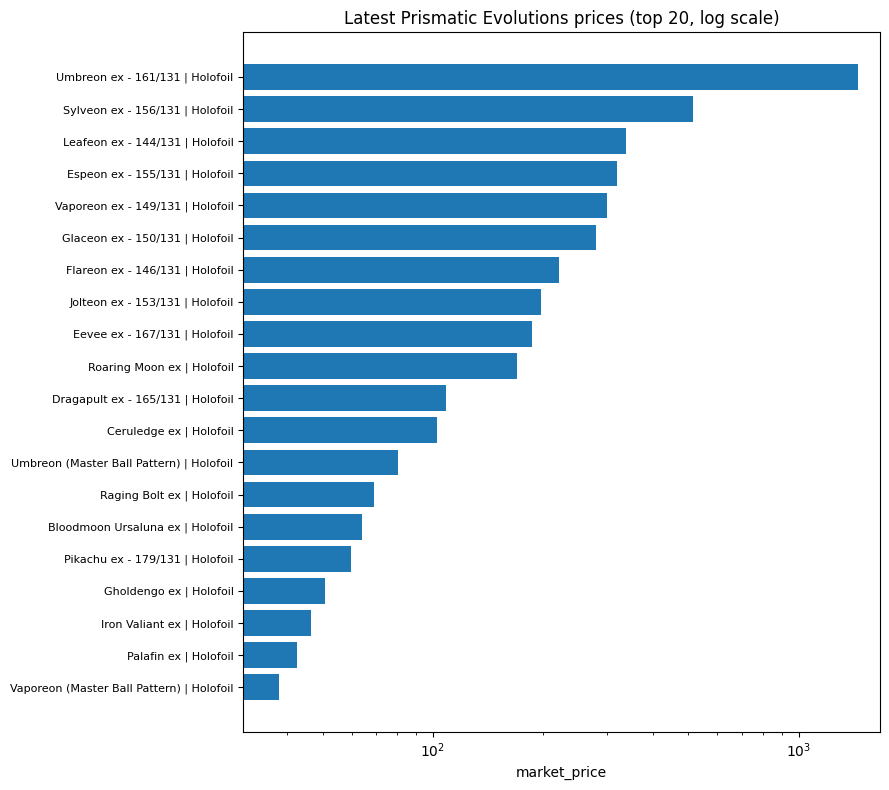

Saved: /Users/ghostof0days/projects/bootcamp/project/data/processed/price_barplot.png


In [10]:
# Latest price by card. Top 20 so names stay readable.
latest = df.sort_values("date").groupby("card_name", as_index=False).tail(1)
latest = latest.sort_values("market_price", ascending=False).head(20)

plt.figure(figsize=(9, 8))
plt.barh(latest["card_name"], latest["market_price"])
plt.xscale("log")
# log x cannot start at 0. floor below the cheapest bar so the axis is valid.
price_floor = latest["market_price"].min() * 0.8
plt.xlim(price_floor, latest["market_price"].max() * 1.15)
plt.yticks(fontsize=8)
plt.title("Latest Prismatic Evolutions prices (top 20, log scale)")
plt.xlabel("market_price")
plt.gca().invert_yaxis()
plt.tight_layout()

plot_path = PROCESSED_DIR / "price_barplot.png"
plt.savefig(plot_path, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")